<a href="https://colab.research.google.com/github/Kavishka2401/CustomerChurnPredictionSystem/blob/master/Check_UnbalanceTechnique.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Mount the google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Core libraries
import os
import pickle
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn utilities
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

# Imbalanced-learn utilities
from imblearn.over_sampling import SMOTE, BorderlineSMOTE, ADASYN

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.metrics import Precision, Recall, AUC

In [7]:
# Path to saved splits
project_path = '/content/drive/MyDrive/NN_Model/Data_Splits/'

# Load train/test splits
with open(project_path + 'X_train.pkl', 'rb') as f:
    X_train = pickle.load(f)

with open(project_path + 'X_test.pkl', 'rb') as f:
    X_test = pickle.load(f)

with open(project_path + 'y_train.pkl', 'rb') as f:
    y_train = pickle.load(f)

with open(project_path + 'y_test.pkl', 'rb') as f:
    y_test = pickle.load(f)

print("Data loaded successfully!")
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

Data loaded successfully!
X_train shape: (5634, 17)
X_test shape: (1409, 17)


In [3]:
def train_model(X_train, y_train, class_weight=None, epochs=50, batch_size=32, validation_split=0.2):
    """
    Create, compile, and train a simple neural network model.
    Returns: trained model and history
    """
    model = Sequential()

    # Input + first hidden
    model.add(Dense(16, activation='relu', input_shape=(X_train.shape[1],)))

    # Second hidden
    model.add(Dense(8, activation='relu'))

    # Output layer
    model.add(Dense(1, activation='sigmoid'))

    # Compile
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=[
            'accuracy',
            Precision(name='precision'),
            Recall(name='recall'),
            AUC(name='auc')
        ]
    )

    # Train
    history = model.fit(
        X_train, y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_split=validation_split,
        class_weight=class_weight,
        verbose=1
    )

    return model, history

In [4]:
def evaluate_model(model, X_train, y_train, X_test, y_test, technique_name='Technique'):
    """
    Evaluates the trained model: prints metrics, classification reports,
    confusion matrices, and plots the confusion matrix.
    """
    # Train metrics
    train_pred = (model.predict(X_train) > 0.5).astype(int)
    train_report = classification_report(y_train, train_pred, output_dict=True, digits=4)
    train_cm = confusion_matrix(y_train, train_pred)

    # Test metrics
    test_pred = (model.predict(X_test) > 0.5).astype(int)
    test_report = classification_report(y_test, test_pred, output_dict=True, digits=4)
    test_cm = confusion_matrix(y_test, test_pred)

    # Print summary
    print(f"--------TRAIN METRICS ({technique_name})--------")
    print(f"Train Accuracy: {train_report['accuracy']:.4f}")
    print(f"Train Precision: {train_report['1']['precision']:.4f}")
    print(f"Train Recall: {train_report['1']['recall']:.4f}")
    print(f"Train F1 Score: {train_report['1']['f1-score']:.4f}\n")

    print(f"--------TEST METRICS ({technique_name})--------")
    print(f"Test Accuracy: {test_report['accuracy']:.4f}")
    print(f"Test Precision: {test_report['1']['precision']:.4f}")
    print(f"Test Recall: {test_report['1']['recall']:.4f}")
    print(f"Test F1 Score: {test_report['1']['f1-score']:.4f}\n")

    print(f"--------TRAIN CLASSIFICATION REPORT ({technique_name})--------")
    print(classification_report(y_train, train_pred, digits=4))

    print(f"--------TEST CLASSIFICATION REPORT ({technique_name})--------")
    print(classification_report(y_test, test_pred, digits=4))

    # Confusion matrix
    print(f"--------Confusion Matrix (Test) ({technique_name})--------")
    print(test_cm)

    # Plot confusion matrix
    plt.figure(figsize=(6,4))
    sns.heatmap(test_cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1], yticklabels=[0,1])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'Confusion Matrix - {technique_name}')
    plt.show()

    # Return reports and CM if needed
    return train_report, test_report, train_cm, test_cm


In [5]:
def save_model_and_metrics(model, history, train_report, test_report, cm, technique_name, save_path='/content/drive/MyDrive/NN_Model/Results/'):
    if not os.path.exists(save_path):
        os.makedirs(save_path)

    model_file = os.path.join(save_path, f'{technique_name}_model.h5')
    model.save(model_file)

    history_file = os.path.join(save_path, f'{technique_name}_history.pkl')
    with open(history_file, 'wb') as f:
        pickle.dump(history.history, f)

    metrics_file = os.path.join(save_path, f'{technique_name}_metrics.pkl')
    with open(metrics_file, 'wb') as f:
        pickle.dump({'train_report': train_report, 'test_report': test_report, 'conf_matrix': cm}, f)

    print(f"Saved {technique_name} model, history, and metrics to {save_path}")

### 1. Class Weights Only

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.3640 - auc: 0.5511 - loss: 0.7155 - precision: 0.2819 - recall: 0.9279 - val_accuracy: 0.6424 - val_auc: 0.7485 - val_loss: 0.6786 - val_precision: 0.4066 - val_recall: 0.7966
Epoch 2/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7023 - auc: 0.8006 - loss: 0.5893 - precision: 0.4750 - recall: 0.8176 - val_accuracy: 0.7072 - val_auc: 0.7931 - val_loss: 0.5848 - val_precision: 0.4638 - val_recall: 0.7593
Epoch 3/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7473 - auc: 0.8193 - loss: 0.5200 - precision: 0.5089 - recall: 0.7587 - val_accuracy: 0.7063 - val_auc: 0.8070 - val_loss: 0.5700 - val_precision: 0.4625 - val_recall: 0.7525
Epoch 4/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7712 - auc: 0.8452 - loss: 0.4818 - precision: 0.5302 - recall: 0.7898 - val_accuracy: 0.7107 - val_auc: 0.8132 - val_loss: 0.5506 - val_precision: 0.4675 - val_recall: 0.7559
Epoch 5/50
141/141 ━━━━━━━━━━━━━

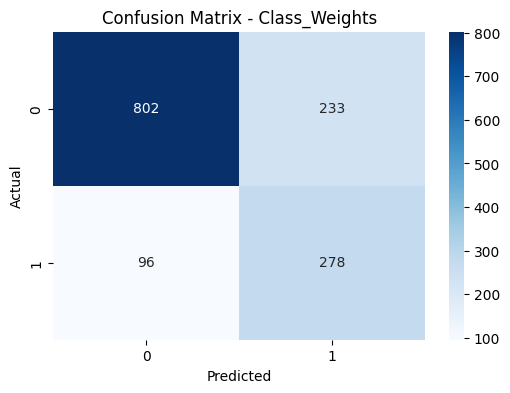

Saved Class_Weights model, history, and metrics to /content/drive/MyDrive/NN_Model/Results/


In [8]:
classes = np.unique(y_train)
class_weights_values = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, class_weights_values))

model, history = train_model(X_train, y_train, class_weight=class_weight_dict)
train_report, test_report, train_cm, test_cm = evaluate_model(model, X_train, y_train, X_test, y_test, technique_name='Class_Weights')
save_model_and_metrics(model, history, train_report, test_report, test_cm, technique_name='Class_Weights')

### 2. SMOTE

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


207/207 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6805 - auc: 0.7383 - loss: 0.5977 - precision: 0.5991 - recall: 0.4808 - val_accuracy: 0.6727 - val_auc: 0.0000e+00 - val_loss: 0.6843 - val_precision: 1.0000 - val_recall: 0.6727
Epoch 2/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7508 - auc: 0.8284 - loss: 0.4912 - precision: 0.6701 - recall: 0.6619 - val_accuracy: 0.7283 - val_auc: 0.0000e+00 - val_loss: 0.6278 - val_precision: 1.0000 - val_recall: 0.7283
Epoch 3/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7545 - auc: 0.8332 - loss: 0.4830 - precision: 0.6642 - recall: 0.7114 - val_accuracy: 0.7307 - val_auc: 0.0000e+00 - val_loss: 0.6251 - val_precision: 1.0000 - val_recall: 0.7307
Epoch 4/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7725 - auc: 0.8470 - loss: 0.4641 - precision: 0.6886 - recall: 0.7253 - val_accuracy: 0.6957 - val_auc: 0.0000e+00 - val_loss: 0.6836 - val_precision: 1.0000 - val_recall: 0.6957
Epoch 5/50
207/207 ━━━━━━━━

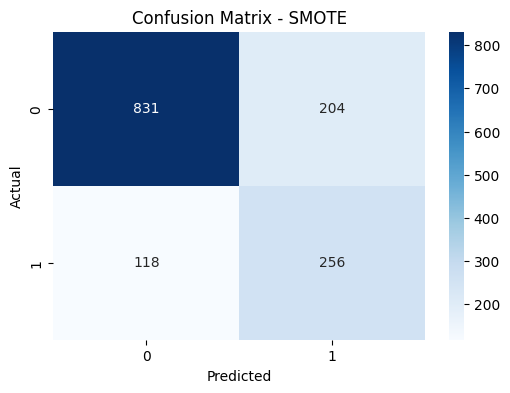

Saved SMOTE model, history, and metrics to /content/drive/MyDrive/NN_Model/Results/


In [9]:
smote = SMOTE(random_state=42)
X_train_aug, y_train_aug = smote.fit_resample(X_train, y_train)

model, history = train_model(X_train_aug, y_train_aug)
train_report, test_report, train_cm, test_cm = evaluate_model(model, X_train_aug, y_train_aug, X_test, y_test, technique_name='SMOTE')
save_model_and_metrics(model, history, train_report, test_report, test_cm, technique_name='SMOTE')

### 3. Borderline SMOTE - 1

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


207/207 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6289 - auc: 0.6745 - loss: 0.6101 - precision: 0.5152 - recall: 0.1704 - val_accuracy: 0.3690 - val_auc: 0.0000e+00 - val_loss: 0.9558 - val_precision: 1.0000 - val_recall: 0.3690
Epoch 2/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7268 - auc: 0.7977 - loss: 0.5272 - precision: 0.6592 - recall: 0.5752 - val_accuracy: 0.6033 - val_auc: 0.0000e+00 - val_loss: 0.7910 - val_precision: 1.0000 - val_recall: 0.6033
Epoch 3/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7446 - auc: 0.8046 - loss: 0.5110 - precision: 0.6541 - recall: 0.6800 - val_accuracy: 0.6582 - val_auc: 0.0000e+00 - val_loss: 0.7300 - val_precision: 1.0000 - val_recall: 0.6582
Epoch 4/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7468 - auc: 0.8174 - loss: 0.4964 - precision: 0.6480 - recall: 0.7059 - val_accuracy: 0.6920 - val_auc: 0.0000e+00 - val_loss: 0.6723 - val_precision: 1.0000 - val_recall: 0.6920
Epoch 5/50
207/207 ━━━━━━━━

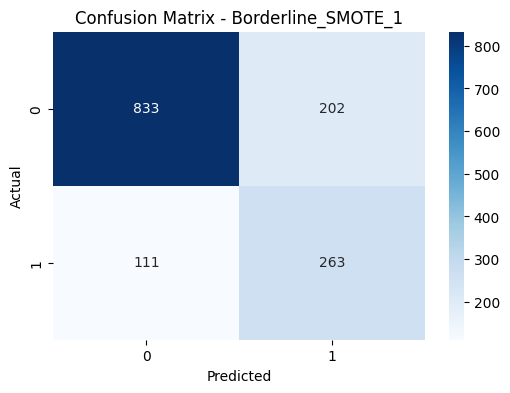

Saved Borderline_SMOTE_1 model, history, and metrics to /content/drive/MyDrive/NN_Model/Results/


In [10]:
smote = BorderlineSMOTE(random_state=42, kind='borderline-1')
X_train_aug, y_train_aug = smote.fit_resample(X_train, y_train)

model, history = train_model(X_train_aug, y_train_aug)
train_report, test_report, train_cm, test_cm = evaluate_model(model, X_train_aug, y_train_aug, X_test, y_test, technique_name='Borderline_SMOTE_1')
save_model_and_metrics(model, history, train_report, test_report, test_cm, technique_name='Borderline_SMOTE_1')

### 4. Borderline SMOTE - 2

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


207/207 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6094 - auc: 0.6682 - loss: 0.6259 - precision: 0.4825 - recall: 0.1679 - val_accuracy: 0.5060 - val_auc: 0.0000e+00 - val_loss: 0.8184 - val_precision: 1.0000 - val_recall: 0.5060
Epoch 2/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7249 - auc: 0.7981 - loss: 0.5196 - precision: 0.6294 - recall: 0.6230 - val_accuracy: 0.6039 - val_auc: 0.0000e+00 - val_loss: 0.7745 - val_precision: 1.0000 - val_recall: 0.6039
Epoch 3/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7350 - auc: 0.8111 - loss: 0.5000 - precision: 0.6372 - recall: 0.6665 - val_accuracy: 0.5797 - val_auc: 0.0000e+00 - val_loss: 0.8070 - val_precision: 1.0000 - val_recall: 0.5797
Epoch 4/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7423 - auc: 0.8114 - loss: 0.5016 - precision: 0.6463 - recall: 0.6789 - val_accuracy: 0.6226 - val_auc: 0.0000e+00 - val_loss: 0.7206 - val_precision: 1.0000 - val_recall: 0.6226
Epoch 5/50
207/207 ━━━━━━━━

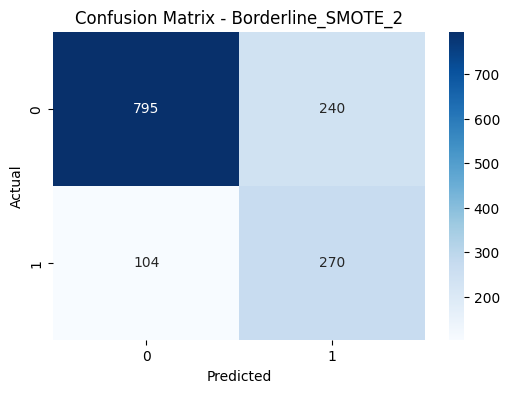

Saved Borderline_SMOTE_2 model, history, and metrics to /content/drive/MyDrive/NN_Model/Results/


In [11]:
smote = BorderlineSMOTE(random_state=42, kind='borderline-2')
X_train_aug, y_train_aug = smote.fit_resample(X_train, y_train)

model, history = train_model(X_train_aug, y_train_aug)
train_report, test_report, train_cm, test_cm = evaluate_model(model, X_train_aug, y_train_aug, X_test, y_test, technique_name='Borderline_SMOTE_2')
save_model_and_metrics(model, history, train_report, test_report, test_cm, technique_name='Borderline_SMOTE_2')

### 5. ADASYN

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


207/207 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6271 - auc: 0.6897 - loss: 0.6073 - precision: 0.4830 - recall: 0.1374 - val_accuracy: 0.5570 - val_auc: 0.0000e+00 - val_loss: 0.8682 - val_precision: 1.0000 - val_recall: 0.5570
Epoch 2/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7427 - auc: 0.8054 - loss: 0.5181 - precision: 0.6575 - recall: 0.6645 - val_accuracy: 0.6533 - val_auc: 0.0000e+00 - val_loss: 0.7542 - val_precision: 1.0000 - val_recall: 0.6533
Epoch 3/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7398 - auc: 0.8169 - loss: 0.5002 - precision: 0.6416 - recall: 0.7017 - val_accuracy: 0.6903 - val_auc: 0.0000e+00 - val_loss: 0.6857 - val_precision: 1.0000 - val_recall: 0.6903
Epoch 4/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7605 - auc: 0.8311 - loss: 0.4858 - precision: 0.6650 - recall: 0.7102 - val_accuracy: 0.6418 - val_auc: 0.0000e+00 - val_loss: 0.7417 - val_precision: 1.0000 - val_recall: 0.6418
Epoch 5/50
207/207 ━━━━━━━━

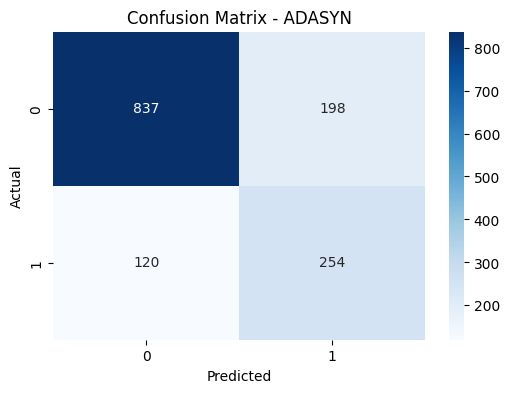

Saved ADASYN model, history, and metrics to /content/drive/MyDrive/NN_Model/Results/


In [12]:
adasyn = ADASYN(random_state=42, n_neighbors=5)
X_train_aug, y_train_aug = adasyn.fit_resample(X_train, y_train)

model, history = train_model(X_train_aug, y_train_aug)
train_report, test_report, train_cm, test_cm = evaluate_model(model, X_train_aug, y_train_aug, X_test, y_test, technique_name='ADASYN')
save_model_and_metrics(model, history, train_report, test_report, test_cm, technique_name='ADASYN')

### 6. SMOTE + Class Weights

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


207/207 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6135 - auc: 0.6726 - loss: 0.6461 - precision: 0.5261 - recall: 0.5483 - val_accuracy: 0.4994 - val_auc: 0.0000e+00 - val_loss: 0.8519 - val_precision: 1.0000 - val_recall: 0.4994
Epoch 2/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7474 - auc: 0.8195 - loss: 0.5135 - precision: 0.6947 - recall: 0.6162 - val_accuracy: 0.6884 - val_auc: 0.0000e+00 - val_loss: 0.7366 - val_precision: 1.0000 - val_recall: 0.6884
Epoch 3/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7622 - auc: 0.8302 - loss: 0.4843 - precision: 0.6688 - recall: 0.7045 - val_accuracy: 0.7361 - val_auc: 0.0000e+00 - val_loss: 0.6657 - val_precision: 1.0000 - val_recall: 0.7361
Epoch 4/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7733 - auc: 0.8403 - loss: 0.4771 - precision: 0.6847 - recall: 0.7340 - val_accuracy: 0.6981 - val_auc: 0.0000e+00 - val_loss: 0.7033 - val_precision: 1.0000 - val_recall: 0.6981
Epoch 5/50
207/207 ━━━━━━━━

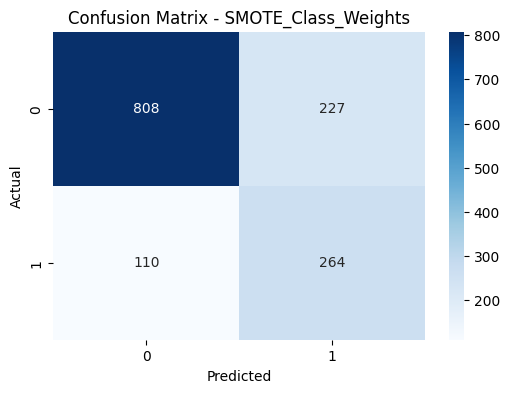

Saved SMOTE_Class_Weights model, history, and metrics to /content/drive/MyDrive/NN_Model/Results/


In [13]:
smote = SMOTE(random_state=42)
X_train_aug, y_train_aug = smote.fit_resample(X_train, y_train)

classes = np.unique(y_train_aug)
class_weights_values = compute_class_weight(class_weight='balanced', classes=classes, y=y_train_aug)
class_weight_dict = dict(zip(classes, class_weights_values))

model, history = train_model(X_train_aug, y_train_aug, class_weight=class_weight_dict)
train_report, test_report, train_cm, test_cm = evaluate_model(model, X_train_aug, y_train_aug, X_test, y_test, technique_name='SMOTE_Class_Weights')
save_model_and_metrics(model, history, train_report, test_report, test_cm, technique_name='SMOTE_Class_Weights')

### 7. Borderline SMOTE - 1 + Class Weights

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


207/207 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6422 - auc: 0.6844 - loss: 0.6231 - precision: 0.5621 - recall: 0.1770 - val_accuracy: 0.4444 - val_auc: 0.0000e+00 - val_loss: 0.8703 - val_precision: 1.0000 - val_recall: 0.4444
Epoch 2/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7376 - auc: 0.8100 - loss: 0.5155 - precision: 0.6675 - recall: 0.6159 - val_accuracy: 0.6159 - val_auc: 0.0000e+00 - val_loss: 0.7500 - val_precision: 1.0000 - val_recall: 0.6159
Epoch 3/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7470 - auc: 0.8183 - loss: 0.4958 - precision: 0.6558 - recall: 0.6657 - val_accuracy: 0.5833 - val_auc: 0.0000e+00 - val_loss: 0.7938 - val_precision: 1.0000 - val_recall: 0.5833
Epoch 4/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7542 - auc: 0.8249 - loss: 0.4884 - precision: 0.6681 - recall: 0.6784 - val_accuracy: 0.6002 - val_auc: 0.0000e+00 - val_loss: 0.7630 - val_precision: 1.0000 - val_recall: 0.6002
Epoch 5/50
207/207 ━━━━━━━━

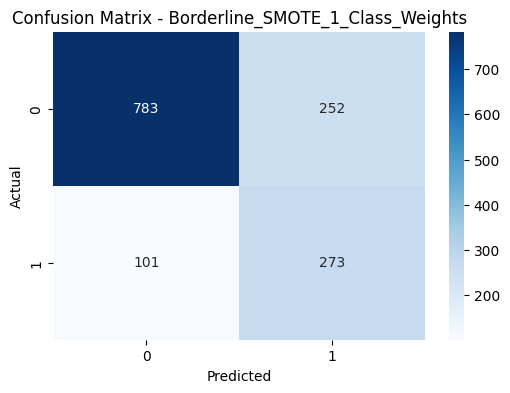

Saved Borderline_SMOTE_1_Class_Weights model, history, and metrics to /content/drive/MyDrive/NN_Model/Results/


In [14]:
smote = BorderlineSMOTE(random_state=42, kind='borderline-1')
X_train_aug, y_train_aug = smote.fit_resample(X_train, y_train)

classes = np.unique(y_train_aug)
class_weights_values = compute_class_weight(class_weight='balanced', classes=classes, y=y_train_aug)
class_weight_dict = dict(zip(classes, class_weights_values))

model, history = train_model(X_train_aug, y_train_aug, class_weight=class_weight_dict)
train_report, test_report, train_cm, test_cm = evaluate_model(model, X_train_aug, y_train_aug, X_test, y_test, technique_name='Borderline_SMOTE_1_Class_Weights')
save_model_and_metrics(model, history, train_report, test_report, test_cm, technique_name='Borderline_SMOTE_1_Class_Weights')

### 8. Borderline SMOTE - 2 + Class Weights

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


207/207 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5105 - auc: 0.5244 - loss: 0.6838 - precision: 0.3537 - recall: 0.3659 - val_accuracy: 0.2295 - val_auc: 0.0000e+00 - val_loss: 0.9226 - val_precision: 1.0000 - val_recall: 0.2295
Epoch 2/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7257 - auc: 0.7917 - loss: 0.5371 - precision: 0.6726 - recall: 0.5127 - val_accuracy: 0.5386 - val_auc: 0.0000e+00 - val_loss: 0.8340 - val_precision: 1.0000 - val_recall: 0.5386
Epoch 3/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7381 - auc: 0.8047 - loss: 0.5131 - precision: 0.6495 - recall: 0.6544 - val_accuracy: 0.6606 - val_auc: 0.0000e+00 - val_loss: 0.7052 - val_precision: 1.0000 - val_recall: 0.6606
Epoch 4/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7352 - auc: 0.8071 - loss: 0.5080 - precision: 0.6397 - recall: 0.6818 - val_accuracy: 0.6455 - val_auc: 0.0000e+00 - val_loss: 0.7121 - val_precision: 1.0000 - val_recall: 0.6455
Epoch 5/50
207/207 ━━━━━━━━

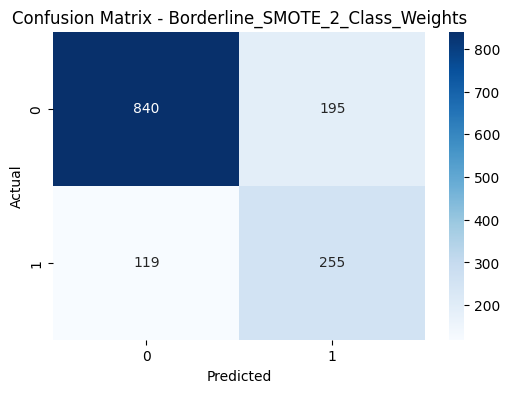

Saved Borderline_SMOTE_2_Class_Weights model, history, and metrics to /content/drive/MyDrive/NN_Model/Results/


In [15]:
smote = BorderlineSMOTE(random_state=42, kind='borderline-2')
X_train_aug, y_train_aug = smote.fit_resample(X_train, y_train)

classes = np.unique(y_train_aug)
class_weights_values = compute_class_weight(class_weight='balanced', classes=classes, y=y_train_aug)
class_weight_dict = dict(zip(classes, class_weights_values))

model, history = train_model(X_train_aug, y_train_aug, class_weight=class_weight_dict)
train_report, test_report, train_cm, test_cm = evaluate_model(model, X_train_aug, y_train_aug, X_test, y_test, technique_name='Borderline_SMOTE_2_Class_Weights')
save_model_and_metrics(model, history, train_report, test_report, test_cm, technique_name='Borderline_SMOTE_2_Class_Weights')

### 9. ADASYN + Class Weights

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


207/207 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.4879 - auc: 0.5280 - loss: 0.7222 - precision: 0.4069 - recall: 0.7453 - val_accuracy: 0.4485 - val_auc: 0.0000e+00 - val_loss: 0.7112 - val_precision: 1.0000 - val_recall: 0.4485
Epoch 2/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7348 - auc: 0.7648 - loss: 0.5916 - precision: 0.7177 - recall: 0.4826 - val_accuracy: 0.5636 - val_auc: 0.0000e+00 - val_loss: 0.7798 - val_precision: 1.0000 - val_recall: 0.5636
Epoch 3/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7584 - auc: 0.8241 - loss: 0.4933 - precision: 0.6788 - recall: 0.6348 - val_accuracy: 0.6158 - val_auc: 0.0000e+00 - val_loss: 0.7497 - val_precision: 1.0000 - val_recall: 0.6158
Epoch 4/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7539 - auc: 0.8289 - loss: 0.4871 - precision: 0.6728 - recall: 0.6687 - val_accuracy: 0.6152 - val_auc: 0.0000e+00 - val_loss: 0.7465 - val_precision: 1.0000 - val_recall: 0.6152
Epoch 5/50
207/207 ━━━━━━━━

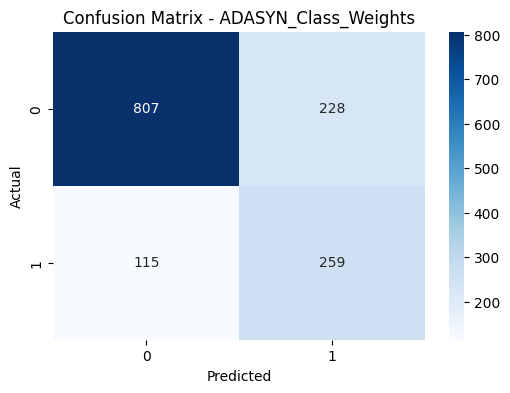

Saved ADASYN_Class_Weights model, history, and metrics to /content/drive/MyDrive/NN_Model/Results/


In [16]:
adasyn = ADASYN(random_state=42, n_neighbors=5)
X_train_aug, y_train_aug = adasyn.fit_resample(X_train, y_train)

classes = np.unique(y_train_aug)
class_weights_values = compute_class_weight(class_weight='balanced', classes=classes, y=y_train_aug)
class_weight_dict = dict(zip(classes, class_weights_values))

model, history = train_model(X_train_aug, y_train_aug, class_weight=class_weight_dict)
train_report, test_report, train_cm, test_cm = evaluate_model(model, X_train_aug, y_train_aug, X_test, y_test, technique_name='ADASYN_Class_Weights')
save_model_and_metrics(model, history, train_report, test_report, test_cm, technique_name='ADASYN_Class_Weights')

# Summary

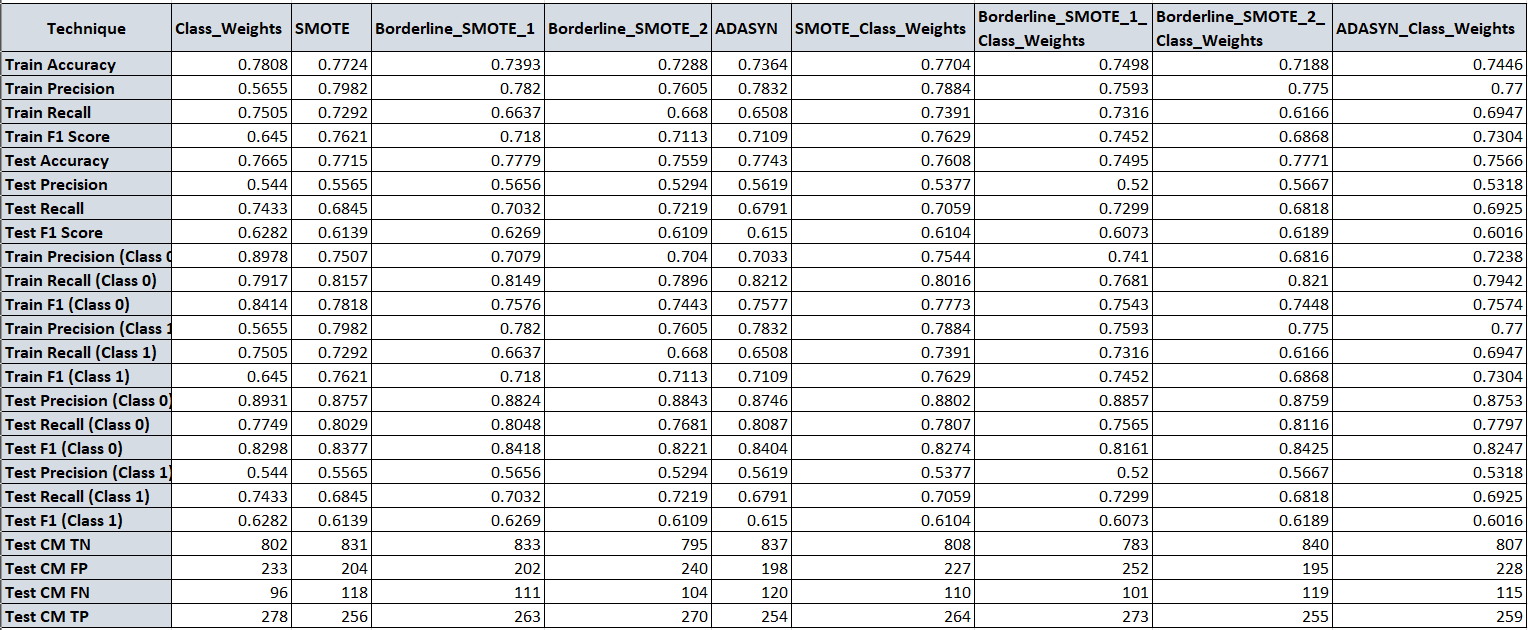